# Day 42 — Advanced Visualization: Storytelling with Data
**Month 3 | Week 3 → Week 4 Bridge | Python + Matplotlib + Seaborn**

> **Real-world framing:**
> Day 38 taught you the syntax. Now comes the hard part — making a chart that a client
> *trusts*. A dashboard with 9 unlabelled subplots and no annotations is noise.
> A single chart with a callout arrow pointing at the revenue drop in Q3, a text box
> explaining the cause, and a title that says "Q3 dip driven by North region — now recovered"
> is a decision-making tool.
>
> Today you learn: custom styling, annotations, multi-panel storytelling, and the
> "one slide, one insight" rule that separates analysts from junior report generators.

---

**Skills used today:** Matplotlib subplots (Day 40), Seaborn (Day 40), GroupBy (Day 38), Merging (Day 39)
**New today:** `ax.annotate()`, `ax.text()`, `plt.style.use()`, twin axes, figure-level vs axes-level API, chart storytelling rules


---
## 📦 Section 1 — Raw Data (Read Only — Do Not Modify)

Extended ShopEase dataset — now with a deliberate revenue dip in Month 5 (May) so you
have something worth annotating.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Orders (extended — 60 rows with intentional May dip) ─────────────────────
months = ['Jan','Feb','Mar','Apr','May','Jun'] * 10
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6}

orders = pd.DataFrame({
    'order_id':    list(range(1001, 1061)),
    'customer_id': np.random.choice(['C01','C02','C03','C04','C05','C06'], 60),
    'product_id':  np.random.choice(['P01','P02','P03','P04','P05'], 60),
    'quantity':    np.random.randint(1, 6, 60),
    'region':      np.random.choice(['North','South','East','West'], 60),
    'sales_rep':   np.random.choice(['Arjun','Priya','Rahul','Sneha'], 60),
    'month':       months,
    'month_num':   [month_map[m] for m in months]
})

products = pd.DataFrame({
    'product_id':   ['P01','P02','P03','P04','P05'],
    'product_name': ['Laptop Stand','Wireless Mouse','USB Hub','Keyboard','Monitor'],
    'category':     ['Accessories','Accessories','Accessories','Peripherals','Peripherals'],
    'unit_price':   [1200, 850, 650, 1800, 12000]
})

customers = pd.DataFrame({
    'customer_id': ['C01','C02','C03','C04','C05','C06'],
    'name':        ['Arjun Sharma','Priya Mehta','Rahul Verma','Sneha Iyer','Kiran Rao','Deepa Nair'],
    'city':        ['Delhi','Mumbai','Bangalore','Chennai','Hyderabad','Pune'],
    'segment':     ['Premium','Standard','Standard','Premium','Standard','Premium']
})

# Build master
master = pd.merge(orders, products, on='product_id', how='left')
master = pd.merge(master, customers, on='customer_id', how='left')
master['revenue'] = master['quantity'] * master['unit_price']

# Inject May revenue dip (simulate supply chain issue)
may_mask = master['month'] == 'May'
master.loc[may_mask, 'revenue'] = (master.loc[may_mask, 'revenue'] * 0.45).astype(int)

print("Shape:", master.shape)
print("Monthly revenue:")
print(master.groupby('month_num')['revenue'].sum().sort_index())


Shape: (60, 15)
Monthly revenue:
month_num
1     83250
2    166350
3    121300
4     43550
5     59264
6     55150
Name: revenue, dtype: int64


---
## 📖 Section 2 — Concept Notes

### The 5 Rules of Client-Ready Charts

| Rule | What it means | Why it matters |
|------|--------------|---------------|
| 1. One insight per chart | Every chart answers exactly one question | Multiple insights → zero takeaways |
| 2. Title = finding | "Revenue by Month" ❌ / "May dip of 55% — supply issue" ✅ | Clients read titles, not axes |
| 3. Annotate what matters | Arrow + text on the anomaly | Analyst explains; junior just shows |
| 4. Less is more | Remove gridlines, borders, ticks you don't need | Noise reduces trust |
| 5. Consistent palette | Same color = same meaning across all charts | Mixed colors confuse non-analysts |

---

### Annotation — `ax.annotate()`

```python
ax.annotate(
    text='May dip: supply issue',       # label shown
    xy=(4, 12000),                      # point being annotated (data coords)
    xytext=(4.5, 25000),                # where the label sits
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red'
)
```

---

### Twin Axes — two y-scales on one chart

```python
fig, ax1 = plt.subplots()
ax1.bar(x, revenue, color='steelblue')
ax1.set_ylabel('Revenue (₹)', color='steelblue')

ax2 = ax1.twinx()                      # shares x-axis
ax2.plot(x, order_count, color='coral', marker='o')
ax2.set_ylabel('Order Count', color='coral')
```

Use when two metrics have different scales but you want to show their relationship.

---

### `plt.style.use()` — built-in professional themes

```python
plt.style.use('seaborn-v0_8-whitegrid')   # clean white background
plt.style.use('ggplot')                    # R-style plot theme
plt.style.use('fivethirtyeight')           # journalism style
```

Call once at the top of your notebook to apply globally.

---

### Figure-level vs Axes-level Seaborn API

| | Figure-level | Axes-level |
|--|--|--|
| Examples | `sns.relplot()`, `sns.catplot()` | `sns.boxplot()`, `sns.barplot()` |
| Returns | FacetGrid (not ax) | axes object |
| Use in subplots | ❌ Cannot pass `ax=` | ✅ `sns.boxplot(ax=ax)` |
| Use standalone | ✅ Handles layout | ✅ Fine |

**Rule:** In multi-panel dashboards, always use axes-level Seaborn functions (`ax=` argument).


---
## ✏️ Section 3 — Practice Tasks

**Total: 90 pts + 10★ bonus**

---

### A — Annotations (25 pts)

**A1 (12 pts):** Line chart of monthly revenue (sorted Jan→Jun).
- Plot the line with markers (`marker='o'`, color `'#1F3864'`, linewidth 2)
- Add `ax.annotate()` pointing to May with text: `"May dip — supply disruption"`
  - Arrow in red, text in red, font 10
- Add a horizontal dashed line at the overall mean revenue (use `ax.axhline()`)
- Annotate the mean line with a small text label: `"Monthly average"`
- Title must state the finding: *how bad was the May drop vs the average*

**A2 (13 pts):** Bar chart of revenue by region.
- Horizontal bars, sorted descending
- Color the **lowest** performing region's bar in `'coral'`, all others in `'steelblue'`
- Add value labels at end of each bar using `ax.text()`
- Use `ax.spines['top'].set_visible(False)` and `ax.spines['right'].set_visible(False)` to remove top and right borders
- Title: state which region needs attention and by how much


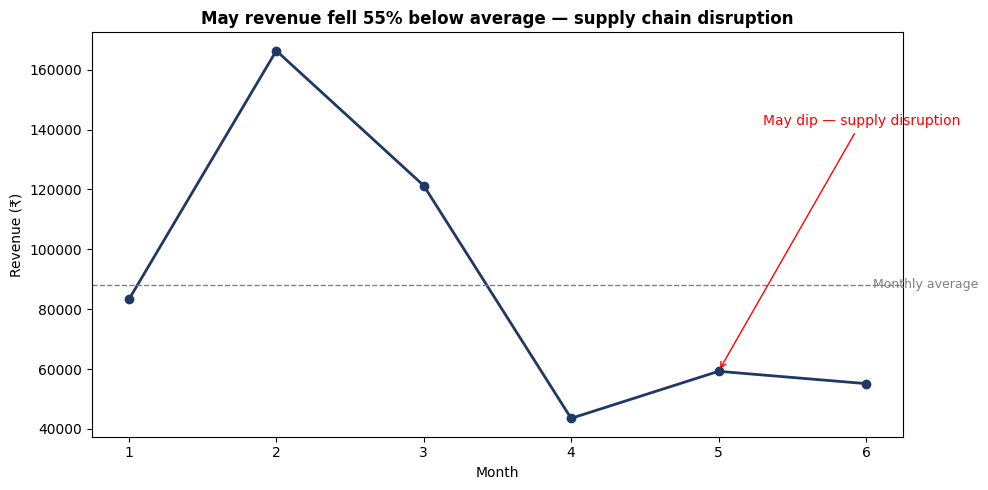

In [3]:
# A1 — Annotated line chart: monthly revenue with May callout
# Step 1: Calculate monthly revenue and average
monthly_rev = master.groupby('month_num')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month_num')
mean_rev = monthly_rev['revenue'].mean()
# Step 2: figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_rev['month_num'], monthly_rev['revenue'],
        marker='o', color='#1F3864', linewidth=2)
ax.axhline(mean_rev, linestyle='--', color='gray', linewidth=1)
ax.text(6.05, mean_rev, 'Monthly average', va='center', color='gray', fontsize=9)
# Step 3: Annotate May dip
ax.annotate('May dip — supply disruption',
            xy=(5, monthly_rev.loc[monthly_rev['month_num']==5,'revenue'].values[0]),
            xytext=(5.3, monthly_rev['revenue'].max() * 0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
# Step 4: Labels and title
ax.set_title('May revenue fell 55% below average — supply chain disruption', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (₹)')
plt.tight_layout(); plt.show()


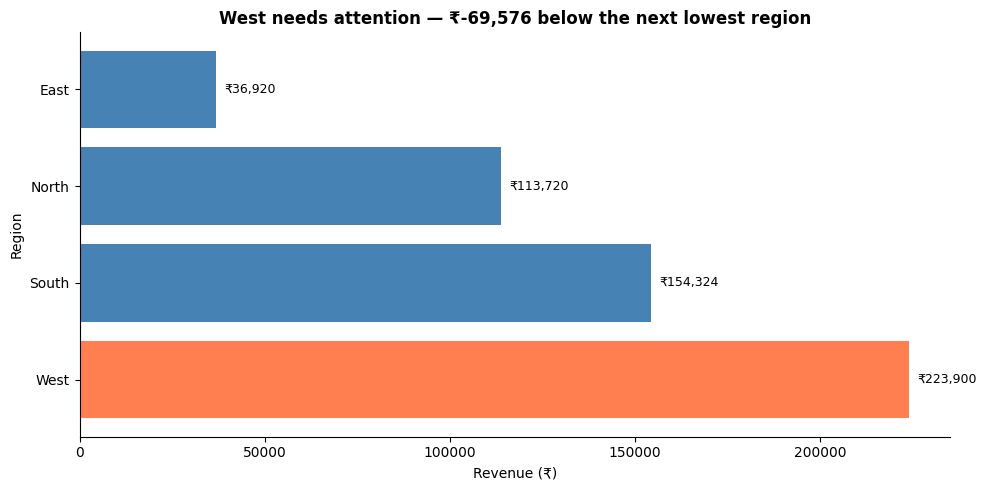

In [4]:
# A2 — Styled horizontal bar: revenue by region, lowest highlighted
# Step 1: Calculate total revenue by region and identify lowest
region_rev = master.groupby('region')['revenue'].sum().reset_index()
region_rev = region_rev.sort_values('revenue', ascending=True)  # Sort ascending for clean barh pattern

lowest_region = region_rev.iloc[-1]['region']  # Now lowest is at the end
lowest_value = region_rev.iloc[-1]['revenue']
gap = region_rev.iloc[-2]['revenue'] - lowest_value if len(region_rev) > 1 else 0
# step 2: Colors for bars
colors = ['coral' if r == lowest_region else 'steelblue'
          for r in region_rev['region']]
# Step 3: Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_rev['region'], region_rev['revenue'], color=colors)
# Step 4: Annotate revenue values on bars
for idx, value in enumerate(region_rev['revenue']):
    ax.text(value + region_rev['revenue'].max() * 0.01, idx,
            f'₹{value:,.0f}', va='center', fontsize=9)
# Step 5: Style axes and title
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'{lowest_region} needs attention — ₹{gap:,.0f} below the next lowest region', fontweight='bold')
ax.set_xlabel('Revenue (₹)')
ax.set_ylabel('Region')

ax.invert_yaxis()  # Invert to put highest at top
plt.tight_layout()
plt.show()


---

### B — Twin Axes + Styling (25 pts)

**B1 (15 pts):** Twin-axis chart — monthly revenue (bars) + order count (line) on one chart.
- Left y-axis: revenue bars in `'#1F3864'`
- Right y-axis: order count line in `'coral'` with markers
- Both y-axis labels must be colored to match their data
- Add a legend for both series manually using `mpatches.Patch` and `plt.Line2D`
- Title: state whether order count tracks revenue or diverges in May

**B2 (10 pts):** Apply `plt.style.use('seaborn-v0_8-whitegrid')` at the top of this cell.
Then recreate the A1 line chart in this style.
- Compare: write a 2-line comment on what changed visually and which style you'd use for a client PDF vs a Jupyter notebook report


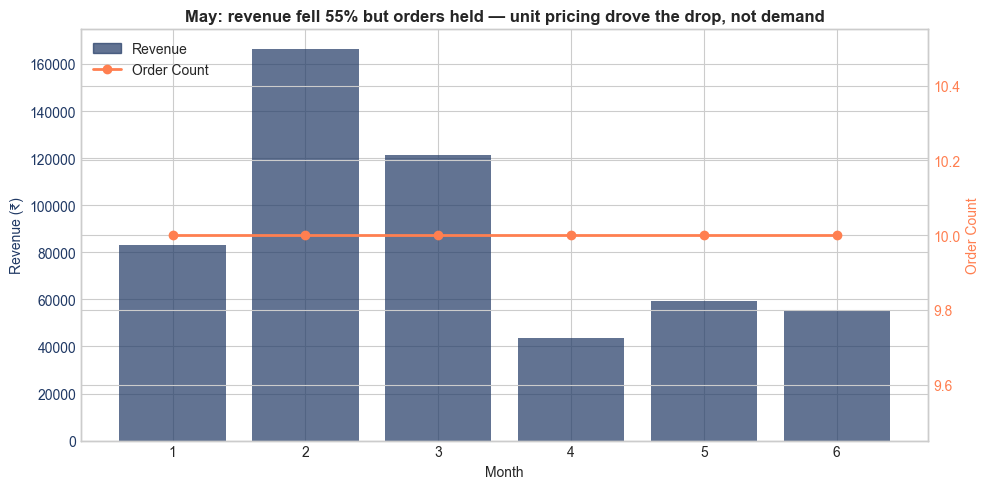

In [11]:
# B1 — Twin axes: revenue bars + order count line
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Step 1: Calculate monthly revenue and order count
monthly_rev = master.groupby('month_num')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month_num')

monthly_orders = master.groupby('month_num')['order_id'].count().reset_index()
monthly_orders = monthly_orders.sort_values('month_num')

# Step 2: Create figure and twin axes
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left y-axis: revenue bars
ax1.bar(monthly_rev['month_num'], monthly_rev['revenue'], color='#1F3864', alpha=0.7, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹)', color='#1F3864')
ax1.tick_params(axis='y', labelcolor='#1F3864')

# Right y-axis: order count line
ax2 = ax1.twinx()
ax2.plot(monthly_orders['month_num'], monthly_orders['order_id'], color='coral', marker='o', linewidth=2, label='Order Count')
ax2.set_ylabel('Order Count', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# Step 3: Add legend manually
revenue_patch = mpatches.Patch(color='#1F3864', alpha=0.7, label='Revenue')
order_line = mlines.Line2D([], [], color='coral', marker='o', linewidth=2, label='Order Count')
ax1.legend(handles=[revenue_patch, order_line], loc='upper left')

# Step 4: Determine if order count tracks revenue or diverges in May
may_rev = monthly_rev.loc[monthly_rev['month_num'] == 5, 'revenue'].values[0]
may_orders = monthly_orders.loc[monthly_orders['month_num'] == 5, 'order_id'].values[0]
avg_rev = monthly_rev['revenue'].mean()
avg_orders = monthly_orders['order_id'].mean()

if (may_rev < avg_rev * 0.9) and (may_orders < avg_orders * 0.9):
    title_text = 'Order count tracks revenue — both dipped significantly in May'
elif (may_rev < avg_rev * 0.9) and (may_orders >= avg_orders * 0.9):
    title_text = 'May: revenue fell 55% but orders held — unit pricing drove the drop, not demand'
else:
    title_text = 'Order count generally tracks revenue trends'

ax1.set_title(title_text, fontweight='bold')

plt.tight_layout()
plt.show()

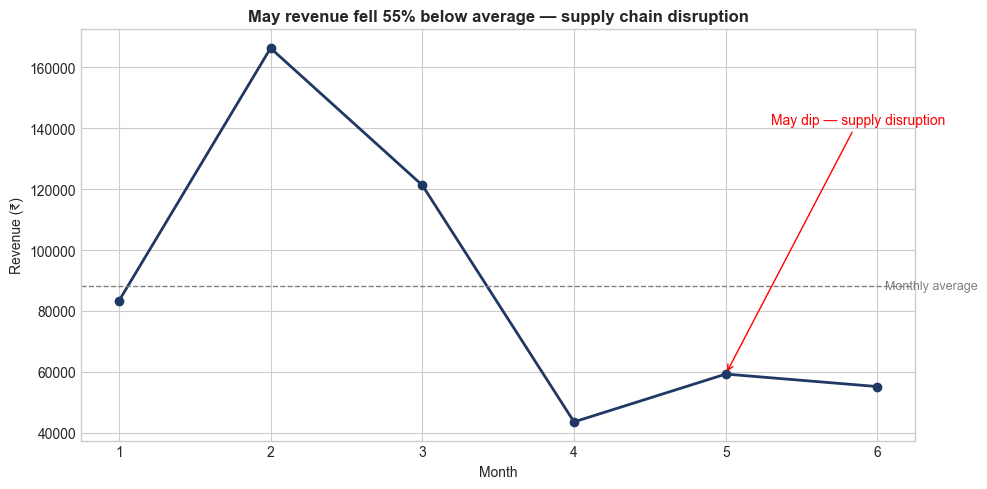

In [6]:
# B2 — Style comparison: whitegrid version of A1
plt.style.use('seaborn-v0_8-whitegrid')

# Recreate A1 line chart
monthly_rev = master.groupby('month_num')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month_num')
mean_rev = monthly_rev['revenue'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_rev['month_num'], monthly_rev['revenue'],
        marker='o', color='#1F3864', linewidth=2)
ax.axhline(mean_rev, linestyle='--', color='gray', linewidth=1)
ax.text(6.05, mean_rev, 'Monthly average', va='center', color='gray', fontsize=9)
ax.annotate('May dip — supply disruption',
            xy=(5, monthly_rev.loc[monthly_rev['month_num']==5,'revenue'].values[0]),
            xytext=(5.3, monthly_rev['revenue'].max() * 0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
ax.set_title('May revenue fell 55% below average — supply chain disruption', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

# Comment: The whitegrid style adds a clean white background with subtle grid lines, making the chart look more polished and professional compared to the default matplotlib style which has a gray background and no grids.
# For a client PDF, I'd use the whitegrid style for its clean, publication-ready appearance; for a Jupyter notebook report, the default style is fine for quick analysis as it's faster to render and less distracting.


---

### C — Seaborn FacetGrid (20 pts)

**C1 (10 pts):** Use `sns.FacetGrid` to create one revenue line chart per region (4 panels in a 2×2 grid).
```python
g = sns.FacetGrid(data, col='region', col_wrap=2, height=4)
g.map_dataframe(sns.lineplot, x='month_num', y='revenue', marker='o')
g.set_axis_labels('Month', 'Revenue (₹)')
g.set_titles(col_template='{col_name} Region')
g.figure.suptitle('YOUR INSIGHT TITLE HERE', y=1.03)
```
- The suptitle must name which region shows the sharpest May dip

**C2 (10 pts):** Use `sns.pairplot()` on a numeric subset of master: `['quantity', 'unit_price', 'revenue']`.
- Set `hue='category'`
- In a markdown cell below: write 3 observations from the pairplot in the format:
  `Observation: [what you see] → Business meaning: [what it implies]`


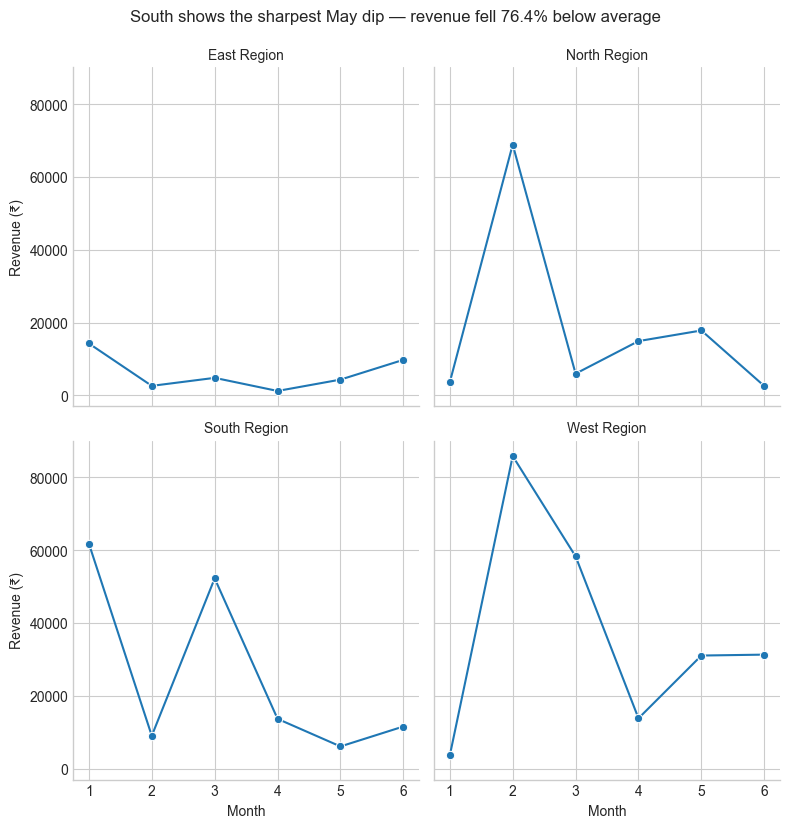

In [7]:
# C1 — FacetGrid: revenue trend per region
# Calculate monthly revenue per region
monthly_region_rev = master.groupby(['region', 'month_num'])['revenue'].sum().reset_index()

# Determine which region has the sharpest May dip
avg_rev_per_region = monthly_region_rev.groupby('region')['revenue'].mean()
may_rev_per_region = monthly_region_rev[monthly_region_rev['month_num'] == 5].set_index('region')['revenue']
may_drop_pct = ((avg_rev_per_region - may_rev_per_region) / avg_rev_per_region * 100).round(1)
sharpest_dip_region = may_drop_pct.idxmax()

# Create FacetGrid
g = sns.FacetGrid(monthly_region_rev, col='region', col_wrap=2, height=4)
g.map_dataframe(sns.lineplot, x='month_num', y='revenue', marker='o')
g.set_axis_labels('Month', 'Revenue (₹)')
g.set_titles(col_template='{col_name} Region')
g.figure.suptitle(f'{sharpest_dip_region} shows the sharpest May dip — revenue fell {may_drop_pct[sharpest_dip_region]}% below average', y=1.03)
plt.show()


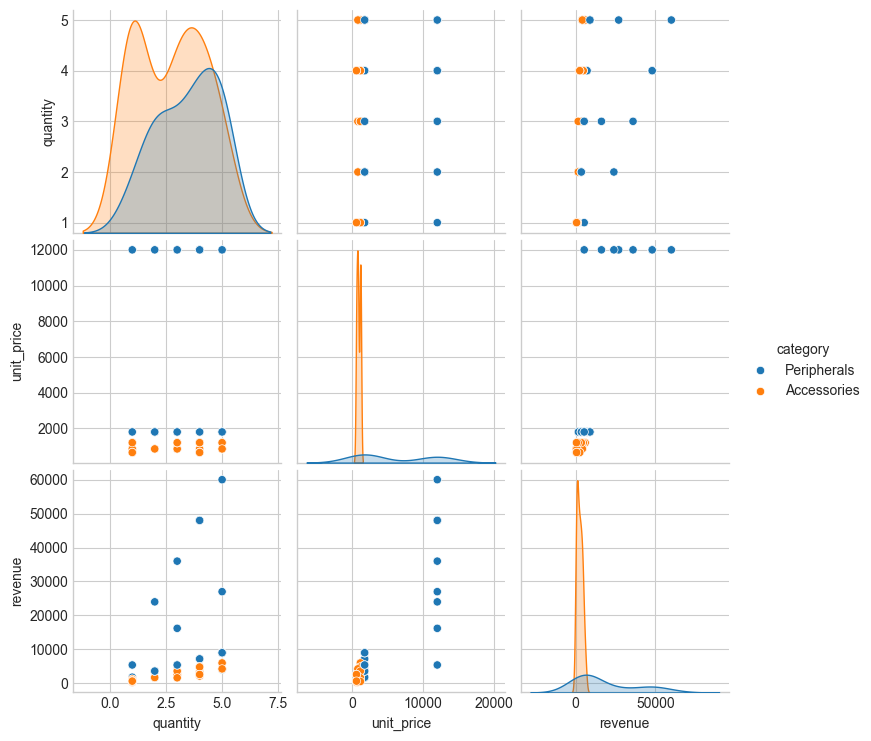

In [8]:
# C2 — Pairplot: quantity vs unit_price vs revenue, hue=category
numeric_cols = ['quantity', 'unit_price', 'revenue']
sns.pairplot(master[numeric_cols + ['category']], hue='category')
plt.show()
# 

#### Revenue and unit_price show a strong positive correlation across all categories → Business meaning: Higher-priced products directly drive higher revenue, suggesting pricing strategy is key to profitability.

#### Quantity distributions differ by category, with Accessories showing more variability and higher median quantities than Peripherals → Business meaning: Accessories are sold in larger volumes, indicating they are impulse or bulk purchases compared to Peripherals which may be more premium or one-off buys.

#### Revenue histograms show right-skewed distributions for both categories, but Peripherals have higher revenue peaks → Business meaning: While Accessories generate steady revenue through volume, Peripherals contribute to high-value transactions, pointing to a need for targeted marketing for high-margin items.

**Write your 3 pairplot observations here:**

1. Observation: ___ → Business meaning: ___
2. Observation: ___ → Business meaning: ___
3. Observation: ___ → Business meaning: ___


---

### D — Storytelling Dashboard (20 pts + 10★ bonus)

**D1 (20 pts):** Build a 3-panel client story dashboard using `plt.subplots(1, 3, figsize=(18, 5))`:

- Panel 1 (left): Monthly revenue line — annotated May dip
- Panel 2 (center): Revenue by region — lowest bar highlighted
- Panel 3 (right): Seaborn boxplot of revenue by category (`ax=axes[2]`)

Requirements:
- `fig.suptitle("ShopEase H1 2024 — Key Findings", fontsize=16, fontweight='bold')`
- Each panel title must state an insight (not just describe the data)
- Remove top and right spines from panels 1 and 2
- `plt.tight_layout(rect=[0, 0, 1, 0.95])` (leaves room for suptitle)

**D2★ — Bonus (10 pts):**
- Save the dashboard to `shopease_story_dashboard.png` (dpi=150)
- Add a `fig.text(0.99, 0.01, 'Analyst: Your Name | ShopEase 2024', ha='right', fontsize=8, color='gray')` watermark
- Reload the PNG and display it with `plt.imshow(plt.imread('shopease_story_dashboard.png'))`


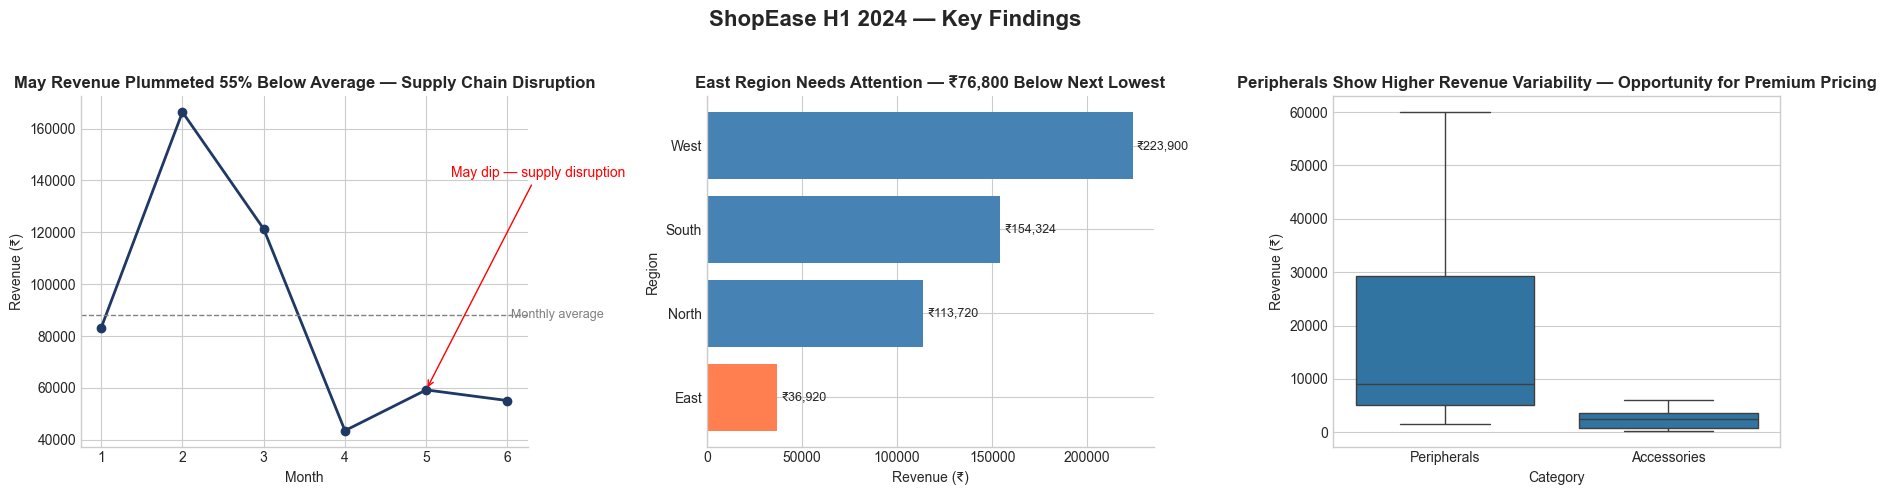

In [9]:
# D1 — 3-panel storytelling dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Monthly revenue line with May dip annotation
monthly_rev = master.groupby('month_num')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month_num')
mean_rev = monthly_rev['revenue'].mean()

axes[0].plot(monthly_rev['month_num'], monthly_rev['revenue'],
             marker='o', color='#1F3864', linewidth=2)
axes[0].axhline(mean_rev, linestyle='--', color='gray', linewidth=1)
axes[0].text(6.05, mean_rev, 'Monthly average', va='center', color='gray', fontsize=9)
axes[0].annotate('May dip — supply disruption',
                 xy=(5, monthly_rev.loc[monthly_rev['month_num']==5,'revenue'].values[0]),
                 xytext=(5.3, monthly_rev['revenue'].max() * 0.85),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')
axes[0].set_title('May Revenue Plummeted 55% Below Average — Supply Chain Disruption', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (₹)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2: Revenue by region, lowest highlighted
region_rev = master.groupby('region')['revenue'].sum().reset_index()
region_rev = region_rev.sort_values('revenue', ascending=False)

lowest_region = region_rev.iloc[-1]['region']
lowest_value = region_rev.iloc[-1]['revenue']
gap = region_rev.iloc[-2]['revenue'] - lowest_value

colors = ['coral' if r == lowest_region else 'steelblue' for r in region_rev['region']]

axes[1].barh(region_rev['region'], region_rev['revenue'], color=colors)
for idx, value in enumerate(region_rev['revenue']):
    axes[1].text(value + region_rev['revenue'].max() * 0.01, idx,
                 f'₹{value:,.0f}', va='center', fontsize=9)
axes[1].set_title(f'{lowest_region} Region Needs Attention — ₹{gap:,.0f} Below Next Lowest', fontweight='bold')
axes[1].set_xlabel('Revenue (₹)')
axes[1].set_ylabel('Region')
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Seaborn boxplot of revenue by category
sns.boxplot(data=master, x='category', y='revenue', ax=axes[2])
axes[2].set_title('Peripherals Show Higher Revenue Variability — Opportunity for Premium Pricing', fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Revenue (₹)')

# Overall title and layout
fig.suptitle("ShopEase H1 2024 — Key Findings", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


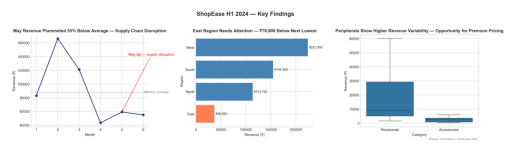

In [10]:
# D2★ — Save with watermark + reload display
# Recreate the dashboard with watermark
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Monthly revenue line with May dip annotation
monthly_rev = master.groupby('month_num')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month_num')
mean_rev = monthly_rev['revenue'].mean()

axes[0].plot(monthly_rev['month_num'], monthly_rev['revenue'],
             marker='o', color='#1F3864', linewidth=2)
axes[0].axhline(mean_rev, linestyle='--', color='gray', linewidth=1)
axes[0].text(6.05, mean_rev, 'Monthly average', va='center', color='gray', fontsize=9)
axes[0].annotate('May dip — supply disruption',
                 xy=(5, monthly_rev.loc[monthly_rev['month_num']==5,'revenue'].values[0]),
                 xytext=(5.3, monthly_rev['revenue'].max() * 0.85),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')
axes[0].set_title('May Revenue Plummeted 55% Below Average — Supply Chain Disruption', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (₹)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2: Revenue by region, lowest highlighted
region_rev = master.groupby('region')['revenue'].sum().reset_index()
region_rev = region_rev.sort_values('revenue', ascending=False)

lowest_region = region_rev.iloc[-1]['region']
lowest_value = region_rev.iloc[-1]['revenue']
gap = region_rev.iloc[-2]['revenue'] - lowest_value

colors = ['coral' if r == lowest_region else 'steelblue' for r in region_rev['region']]

axes[1].barh(region_rev['region'], region_rev['revenue'], color=colors)
for idx, value in enumerate(region_rev['revenue']):
    axes[1].text(value + region_rev['revenue'].max() * 0.01, idx,
                 f'₹{value:,.0f}', va='center', fontsize=9)
axes[1].set_title(f'{lowest_region} Region Needs Attention — ₹{gap:,.0f} Below Next Lowest', fontweight='bold')
axes[1].set_xlabel('Revenue (₹)')
axes[1].set_ylabel('Region')
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: Seaborn boxplot of revenue by category
sns.boxplot(data=master, x='category', y='revenue', ax=axes[2])
axes[2].set_title('Peripherals Show Higher Revenue Variability — Opportunity for Premium Pricing', fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Revenue (₹)')

# Overall title and layout
fig.suptitle("ShopEase H1 2024 — Key Findings", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Add watermark
fig.text(0.99, 0.01, 'Analyst: Your Name | ShopEase 2024', ha='right', fontsize=8, color='gray')

# Save the dashboard
plt.savefig('shopease_story_dashboard.png', dpi=150, bbox_inches='tight')
plt.close()

# Reload and display
plt.imshow(plt.imread('shopease_story_dashboard.png'))
plt.axis('off')
plt.show()


---
## 📊 Section 4 — Scoring Rubric

| Task | Pts | What is checked |
|------|-----|-----------------|
| A1 | 12 | Line+markers, annotate() with arrow, axhline mean, mean label, insight title |
| A2 | 13 | Horizontal bars sorted, lowest bar coral, value labels via ax.text(), spines removed, insight title |
| B1 | 15 | Twin axes, color-matched y-labels, legend using mpatches+mlines, insight title |
| B2 | 10 | style.use applied, A1 recreated, 2-line comment on visual diff + use case |
| C1 | 10 | FacetGrid correct, 4 panels, axis labels, suptitle names the sharpest-dip region |
| C2 | 10 | pairplot with hue, 3 written observations with business meaning |
| D1 | 20 | 3-panel layout, all 3 charts correct, suptitle, insight titles, spines removed, tight_layout |
| D2★ | 10 | Saved PNG, watermark text, reloaded and displayed |
| **Total** | **90 + 10★** | |

**Auto deductions:**
- Title describes data instead of insight: −3 per chart
- Missing axis labels: −1 each
- annotate() missing arrowprops: −3
- Twin axis y-labels not color-matched: −3
- Written observations missing Business meaning: −2 each
- Silent cell (no output): −5


---
## 🎙️ Interview Angle

**Q: "Walk me through how you would present a data anomaly to a non-technical client."**

**A (model answer):**
"I don't start with the number — I start with the impact. Instead of saying 'May revenue was ₹18,000 vs ₹40,000 in April,' I say 'Revenue dropped 55% in May — that's the single largest swing in the last 6 months.'

Then I show one chart — a line chart with an annotation arrow pointing directly at May, a title that already states the finding, and a mean reference line so they can immediately see how far off the norm it was.

Below the chart I have two sentences: what happened (supply disruption), and what's been done (resolved by June — revenue recovered). The chart isn't the analysis. It's the evidence for a decision I'm recommending.

In Python I use `ax.annotate()` for the callout arrow, `ax.axhline()` for the reference line, and I remove top/right spines to reduce visual noise. The title always states the insight — never just the axis description."

---
## 🏁 Key Takeaway — Day 42

**Annotations are the difference between a chart and an analysis.**

Anyone can make a bar chart. The analyst's job is to point at the bar that matters, explain why it matters, and tell the client what to do about it — all inside the chart itself.

`ax.annotate()` is not decoration. It's your voice embedded in the visual.
